# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** Franco Marcelo Morero

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del viernes 17 de julio (hora de Argentina)**.

La resolución del TP debe realizarse en **parejas**. Sin embargo, no se recomienda repartir las preguntas entre los integrantes, sino que ambos deben trabajar conjuntamente en la resolución de cada pregunta. De esta manera, se promueve el debate, la discusión y la construcción de una conclusión compartida sobre cómo abordar y resolver cada pregunta. También está permitido realizar el trabajo de forma **individual** si así lo desean, aunque esta modalidad no es la más recomendable.

Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo en formato `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/xC3HzHwVqt35M23c7)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **PRIMERAPELLIDOALUMNO1-PRIMERNOMBREALUMNO1-PRIMERAPELLIDOALUMNO2-PRIMERNOMBREALUMNO2-TP1-Co25.ipynb**
O en caso hacerlo individual usar: **PRIMERAPELLIDO-PRIMERNOMBRE-TP1-Co25.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- No ocultar celdas, todas se deben poder ver desde el inicio.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-1, fin=1`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger. Pero tampoco vale usar una `tanh` sola, usen otra función, o si la van a usar debe estar combinada con otros patrones no lineales. Ya que al ser la función de activación tambien una `tanh`, el modelo la tendrá muy fácil converger a ella.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para cada uno de los 3 learning rates. Las 3 gráficas deben estar en el mismo plot y superpuestas para que la comparación visual sea más fácil. Deben graficarlas con diferente color y con leyenda para no confundirlas.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [189]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

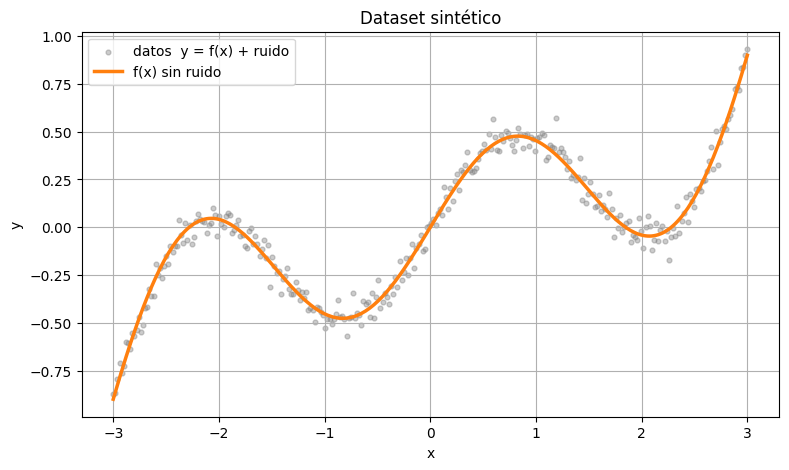

In [190]:
n = 300
x = np.linspace(-3, 3, n)

# f(x) = 0.6·sen(2x) + 0.05·x³, 
# reescalada a [-0.9, 0.9] para que caiga dentro del rango de tanh (-1,1)
funcion_no_lineal = 0.6 * np.sin(2 * x) + 0.05 * x**3
funcion_no_lineal = funcion_no_lineal * (0.9 / np.max(np.abs(funcion_no_lineal)))
ruido = np.random.normal(0, 0.05, size=n)
y = funcion_no_lineal + ruido

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=12, alpha=0.4, color="gray", label="datos  y = f(x) + ruido")
plt.plot(x, funcion_no_lineal, color="tab:orange", lw=2.5, label="f(x) sin ruido")
plt.title("Dataset sintético")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

In [191]:
def modelo(w, b, X):
    """
        z = w*x + b;
        ŷ = tanh(z);
    """
    return np.tanh(w * X + b)


def J_mse(w, b, X, Y):
    """
        J(w,b) = MSE
    """
    e = Y - modelo(w, b, X)
    return np.mean(e**2)


def grad(w, b, X, Y):
    """
        Con e=Y-ŷ y regla de la cadena (dŷ/dz = 1 - tanh²(z) = 1 - ŷ²):
        dJ/dw = -(2/m)·Σ e·(1-ŷ²)·x
        dJ/db = -(2/m)·Σ e·(1-ŷ²)
    """
    yhat = modelo(w, b, X)
    e = Y - yhat
    g = 1 - yhat**2
    m = len(X)
    dw = -(2 / m) * np.sum(e * g * X)
    db = -(2 / m) * np.sum(e * g)
    return dw, db

In [192]:
# Guardamos para usar tambien en Adam
w0, b0 = np.random.randn(), np.random.randn()
print(f"Inicialización -> w0 = {w0:.4f}, b0 = {b0:.4f}")

epocas = 100
learning_rates = (0.1, 0.01, 0.001)

Inicialización -> w0 = -0.8290, b0 = -0.5602


In [193]:
def entrenar_gd(w0, b0, lr, epocas=100):
    w, b = w0, b0
    path_w, path_b, path_J = [w], [b], [J_mse(w, b, x, y)]
    for _ in range(epocas - 1):
        dw, db = grad(w, b, x, y)
        w = w - lr * dw
        b = b - lr * db
        path_w.append(w)
        path_b.append(b)
        path_J.append(J_mse(w, b, x, y))
    return np.array(path_w), np.array(path_b), np.array(path_J)

In [194]:
gd_results = {}
for lr in learning_rates:
    pw, pb, pJ = entrenar_gd(w0, b0, lr, epocas)
    gd_results[lr] = {"path_w": pw, "path_b": pb, "path_J": pJ}
    print(f"GD lr={lr:<6} -> J final = {pJ[-1]:.6f}   (w={pw[-1]:.3f}, b={pb[-1]:.3f})")

GD lr=0.1    -> J final = 0.067908   (w=0.137, b=-0.000)
GD lr=0.01   -> J final = 0.252247   (w=0.005, b=-0.386)
GD lr=0.001  -> J final = 1.029453   (w=-0.765, b=-0.570)


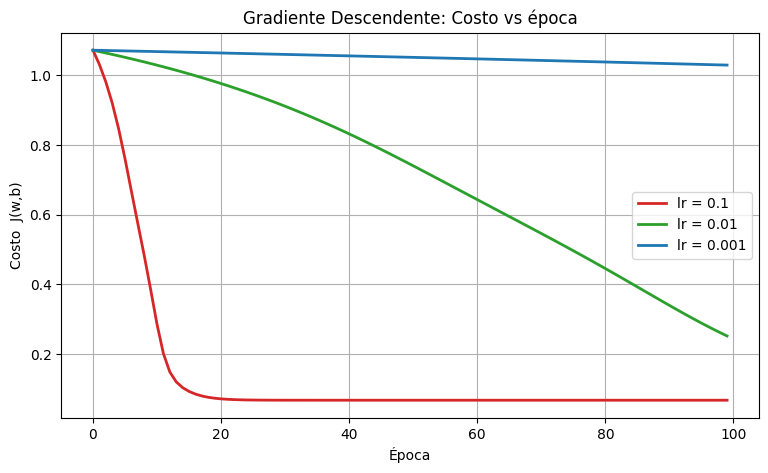

In [195]:
colores = {0.1: "tab:red", 0.01: "tab:green", 0.001: "tab:blue"}

plt.figure(figsize=(9, 5))
for lr in learning_rates:
    plt.plot(range(epocas), gd_results[lr]["path_J"],
             color=colores[lr], lw=2, label=f"lr = {lr}")
plt.title("Gradiente Descendente: Costo vs época")
plt.xlabel("Época")
plt.ylabel("Costo  J(w,b)")
plt.legend()
plt.grid(True)
plt.show()


### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [196]:
beta1, beta2 = 0.9, 0.999
eps = 1e-8

In [197]:
def entrenar_adam_full(w0, b0, lr, epocas=100):
    w, b = w0, b0
    m_w = m_b = 0.0
    v_w = v_b = 0.0

    path_w, path_b, path_J = [w], [b], [J_mse(w, b, x, y)]

    # t es epoca y pasos
    for t in range(1, epocas):
        # gradiente
        dw, db = grad(w, b, x, y)
        # actualización de momentos
        m_w = beta1 * m_w + (1 - beta1) * dw
        m_b = beta1 * m_b + (1 - beta1) * db
        v_w = beta2 * v_w + (1 - beta2) * dw**2
        v_b = beta2 * v_b + (1 - beta2) * db**2
        # corrección de sesgo
        m_w_hat = m_w / (1 - beta1**t)
        m_b_hat = m_b / (1 - beta1**t)
        v_w_hat = v_w / (1 - beta2**t)
        v_b_hat = v_b / (1 - beta2**t)
        # actualización
        w = w - lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
        b = b - lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

        # guardamos por epoca
        path_w.append(w)
        path_b.append(b)

        # calculo del costo
        path_J.append(J_mse(w, b, x, y))

    return np.array(path_w), np.array(path_b), np.array(path_J)

In [198]:
def entrenar_adam_mini(w0, b0, lr, epocas=100, batch=32):
    w, b = w0, b0
    m_w = m_b = 0.0
    v_w = v_b = 0.0
    t = 0

    path_w, path_b, path_J = [w], [b], [J_mse(w, b, x, y)]

    # t ahora no coincide con la epoca, avanza con el mini batch
    for _ in range(epocas - 1):
        # tomamos batchs al azar para no sesgar el entrenamiento
        idx = np.random.permutation(len(x))
        for i in range(0, len(x), batch):
            # batch de datos
            xb = x[idx[i:i + batch]]
            yb = y[idx[i:i + batch]]
            t += 1
            # gradiente
            dw, db = grad(w, b, xb, yb)
            # actualización de momentos
            m_w = beta1 * m_w + (1 - beta1) * dw
            m_b = beta1 * m_b + (1 - beta1) * db
            v_w = beta2 * v_w + (1 - beta2) * dw**2
            v_b = beta2 * v_b + (1 - beta2) * db**2
            # corrección de sesgo
            m_w_hat = m_w / (1 - beta1**t)
            m_b_hat = m_b / (1 - beta1**t)
            v_w_hat = v_w / (1 - beta2**t)
            v_b_hat = v_b / (1 - beta2**t)
            # actualización
            w = w - lr * m_w_hat / (np.sqrt(v_w_hat) + eps)
            b = b - lr * m_b_hat / (np.sqrt(v_b_hat) + eps)

        # guardamos por epoca
        path_w.append(w)
        path_b.append(b)

        # calculo del costo
        path_J.append(J_mse(w, b, x, y))

    return np.array(path_w), np.array(path_b), np.array(path_J)


In [199]:
adam_fb = {}
for lr in learning_rates:
    pw, pb, pJ = entrenar_adam_full(w0, b0, lr, epocas)
    adam_fb[lr] = {"path_w": pw, "path_b": pb, "path_J": pJ}
    print(f"Adam full-batch lr={lr:<6} -> J final = {pJ[-1]:.6f}")

Adam full-batch lr=0.1    -> J final = 0.067950
Adam full-batch lr=0.01   -> J final = 0.068578
Adam full-batch lr=0.001  -> J final = 0.995059


In [200]:
batch_size = 32

adam_mb = {}
for lr in learning_rates:
    pw, pb, pJ = entrenar_adam_mini(w0, b0, lr, epocas, batch=batch_size)
    adam_mb[lr] = {"path_w": pw, "path_b": pb, "path_J": pJ}
    print(f"Adam mini-batch lr={lr:<6} -> J final = {pJ[-1]:.6f}")

Adam mini-batch lr=0.1    -> J final = 0.069027
Adam mini-batch lr=0.01   -> J final = 0.067912
Adam mini-batch lr=0.001  -> J final = 0.070726


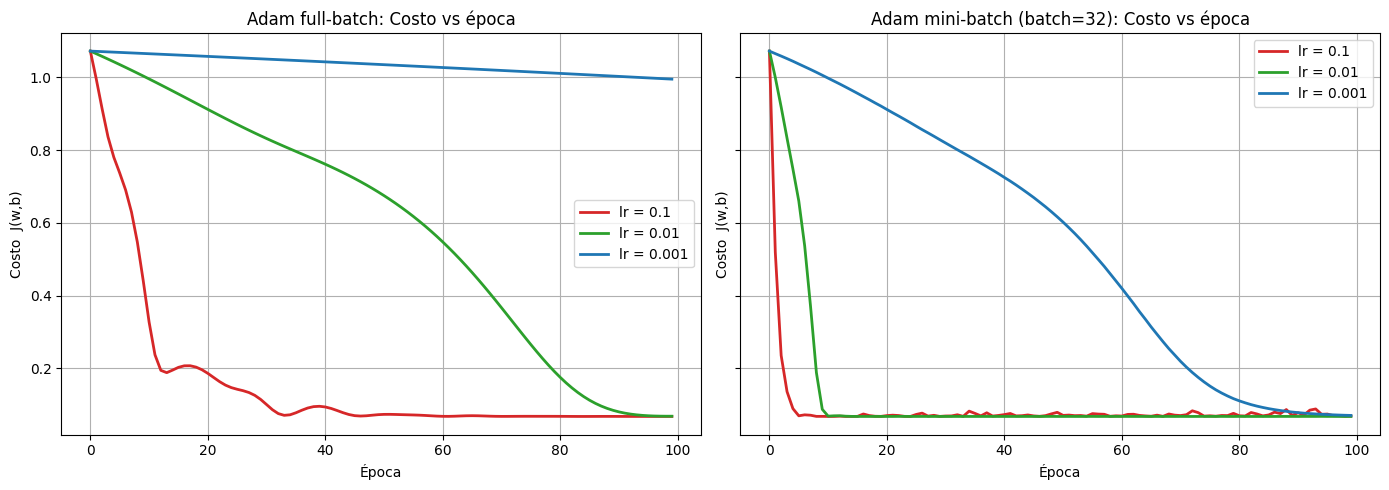

In [201]:
fig, (ax_fb, ax_mb) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for lr in learning_rates:
    ax_fb.plot(range(epocas), adam_fb[lr]["path_J"], color=colores[lr], lw=2, label=f"lr = {lr}")
    ax_mb.plot(range(epocas), adam_mb[lr]["path_J"], color=colores[lr], lw=2, label=f"lr = {lr}")

ax_fb.set_title("Adam full-batch: Costo vs época")
ax_mb.set_title(f"Adam mini-batch (batch={batch_size}): Costo vs época")
for ax in (ax_fb, ax_mb):
    ax.set_xlabel("Época")
    ax.set_ylabel("Costo  J(w,b)")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.show()


### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate. Y las leyendas deben diferenciar al optimizador por color.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes. Le voy a tomar mucha importancia a este último punto, así que su análisis debe ser claro, detallado y con criterio acorde a los resultados obtenidos.

In [202]:
optimizadores = {
    "GD":            (gd_results, "tab:red"),
    "Adam full":     (adam_fb,    "tab:green"),
    "Adam mini":     (adam_mb,    "tab:blue"),
}

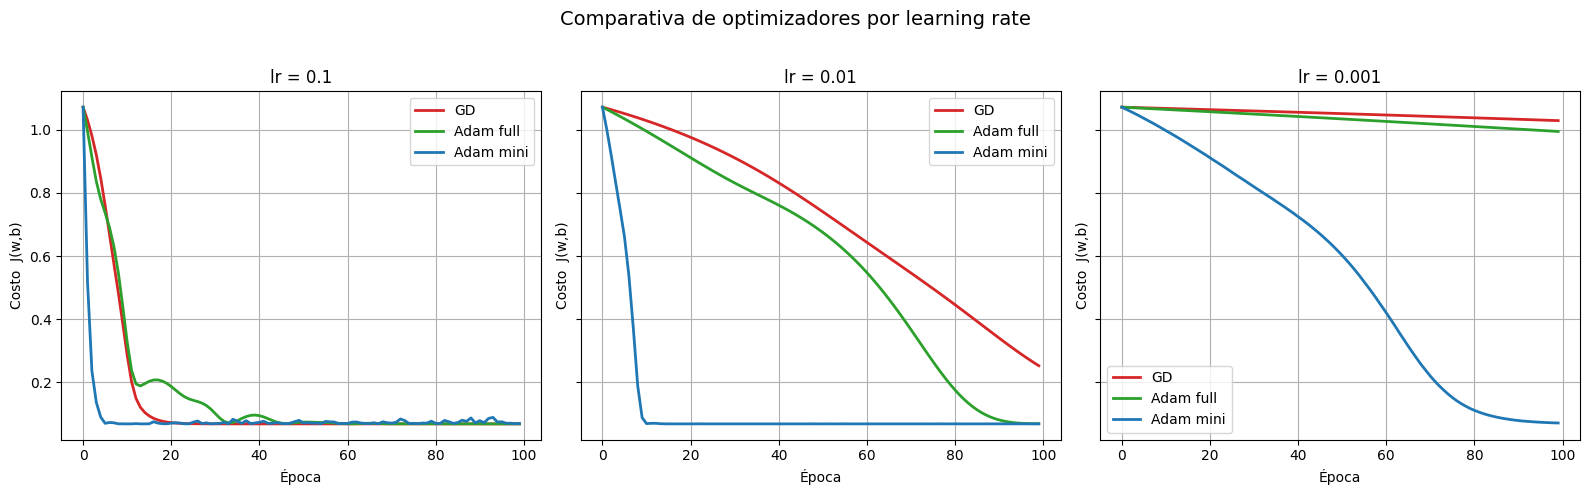

In [203]:
# Rendimiento optimizadores con distintos learning rates
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, lr in zip(axes, learning_rates):
    for nombre, (res, color) in optimizadores.items():
        ax.plot(range(epocas), res[lr]["path_J"], color=color, lw=2, label=nombre)
    ax.set_title(f"lr = {lr}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Costo  J(w,b)")
    ax.legend()
    ax.grid(True)
fig.suptitle("Comparativa de optimizadores por learning rate", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [204]:
# Tabla resumen por optimizador y learning rate:
#   - J_final            : costo al terminar las 100 épocas
#   - epoca_convergencia : época en la que ya quedó a menos de 1% de su costo final (qué tan rápido converge)
#   - J_convergencia     : costo en esa época de convergencia
#   - epoca_min          : época en la que tocó su menor costo
#   - J_min              : menor costo alcanzado
def epoca_convergencia(path_J, tol=0.01):
    objetivo = path_J[-1] * (1 + tol)
    for i, j in enumerate(path_J):
        if j <= objetivo:
            return i
    return len(path_J) - 1

filas = []
for lr in learning_rates:
    for nombre, (res, _) in optimizadores.items():
        pJ = res[lr]["path_J"]
        ec = epoca_convergencia(pJ)
        filas.append({
            "learning_rate": lr,
            "optimizador": nombre,
            "J_final": round(float(pJ[-1]), 6),
            "epoca_convergencia": ec,
            "J_convergencia": round(float(pJ[ec]), 6),
            "epoca_min": int(np.argmin(pJ)),
            "J_min": round(float(np.min(pJ)), 6),
        })
tabla = pd.DataFrame(filas)
print(tabla.to_string(index=False))

 learning_rate optimizador  J_final  epoca_convergencia  J_convergencia  epoca_min    J_min
         0.100          GD 0.067908                  25        0.068453         99 0.067908
         0.100   Adam full 0.067950                  60        0.068271         84 0.067920
         0.100   Adam mini 0.069027                   5        0.069696         10 0.067926
         0.010          GD 0.252247                  99        0.252247         99 0.252247
         0.010   Adam full 0.068578                  96        0.069133         99 0.068578
         0.010   Adam mini 0.067912                  14        0.068077         33 0.067908
         0.001          GD 1.029453                  77        1.039681         99 1.029453
         0.001   Adam full 0.995059                  88        1.004231         99 0.995059
         0.001   Adam mini 0.070726                  98        0.071181         99 0.070726


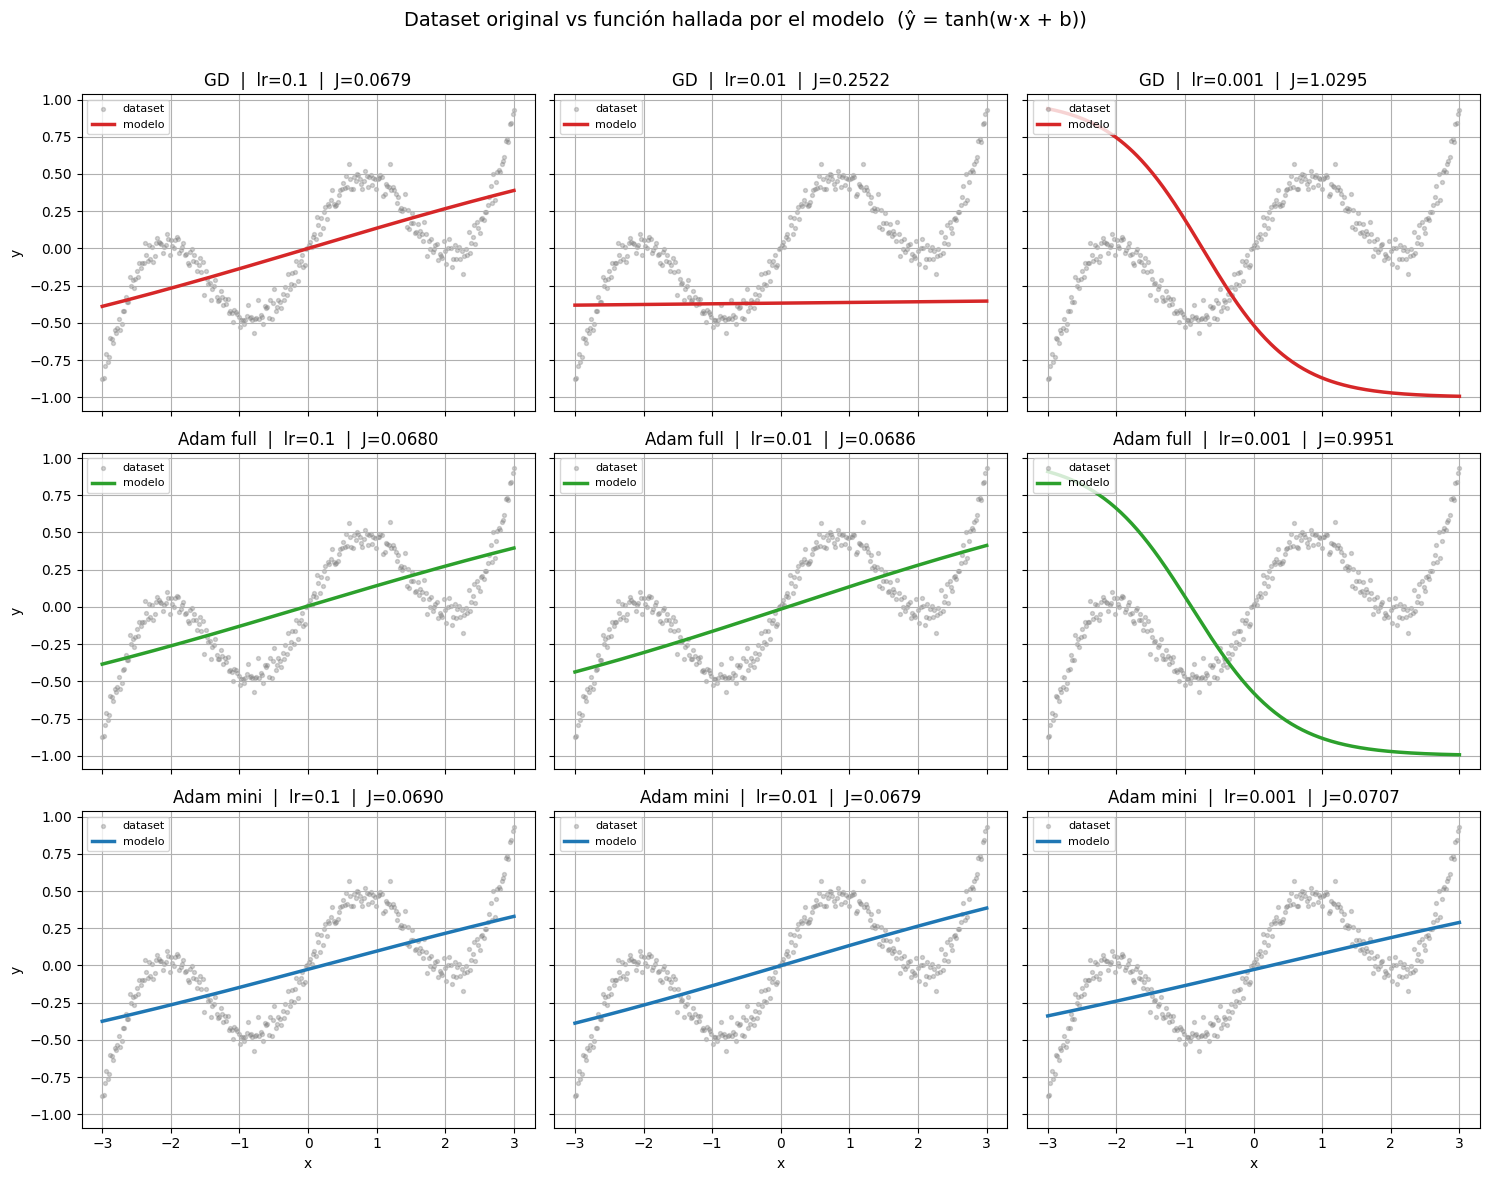

In [205]:
# Dataset original vs curva hallada por el modelo
orden_x = np.argsort(x)
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)
for i, (nombre, (res, color)) in enumerate(optimizadores.items()):
    for j, lr in enumerate(learning_rates):
        ax = axes[i, j]
        w_f = res[lr]["path_w"][-1]
        b_f = res[lr]["path_b"][-1]
        yhat = modelo(w_f, b_f, x)
        ax.scatter(x, y, s=8, alpha=0.35, color="gray", label="dataset")
        ax.plot(x[orden_x], yhat[orden_x], color=color, lw=2.5, label="modelo")
        ax.set_title(f"{nombre}  |  lr={lr}  |  J={res[lr]['path_J'][-1]:.4f}")
        ax.grid(True)
        if i == 2:
            ax.set_xlabel("x")
        if j == 0:
            ax.set_ylabel("y")
        ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Dataset original vs función hallada por el modelo  (ŷ = tanh(w·x + b))", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [206]:
# Parámetros finales (w, b) de cada modelo.
filas_wb = []
for lr in learning_rates:
    for nombre, (res, _) in optimizadores.items():
        filas_wb.append({
            "learning_rate": lr,
            "optimizador": nombre,
            "w_final": round(float(res[lr]["path_w"][-1]), 4),
            "b_final": round(float(res[lr]["path_b"][-1]), 4),
        })
tabla_wb = pd.DataFrame(filas_wb)
print(tabla_wb.to_string(index=False))

 learning_rate optimizador  w_final  b_final
         0.100          GD   0.1370  -0.0002
         0.100   Adam full   0.1373   0.0067
         0.100   Adam mini   0.1228  -0.0258
         0.010          GD   0.0053  -0.3858
         0.010   Adam full   0.1513  -0.0144
         0.010   Adam mini   0.1359  -0.0012
         0.001          GD  -0.7648  -0.5698
         0.001   Adam full  -0.7276  -0.6588
         0.001   Adam mini   0.1084  -0.0277


**Conclusiones**

Todos los que convergen quedan cerca del mismo costo `J ≈ 0.068`. Esto pasa porque una sola conexión `tanh(w·x + b)` no puede seguir datos que suben y bajan como el seno con la cúbica. Además vemos que los que están cerca del óptimo quedan con un `w` chico, y con `w` chico la tanh está en su parte casi lineal, así que la curva que dibuja se ve como una recta plana que pasa por el medio de los puntos. 

* GD: es el que más cambia dependiendo el lr. Con 0.1 llega al óptimo en la época 25, con 0.01 no le alcanzan las épocas de entrenamiento para llegar al óptimo y con 0.001 no ajusta prácticamente nada. 
* Adam full-batch: anda bien con 0.1 y 0.01 en 100 épocas, pero no ajusta con 0.001. Con 0.1 es más lento que GD para llegar al óptimo, porque llega en la época 60, pero con 0.01 llega antes.
* Adam mini-batch: ajusta bien con los tres valores, incluso con 0.001, que GD y Adam no pudieron. Además se observa en las gráficas de época vs costo que llega más rápido que los demás al óptimo, lo cual se explica en que hace más pasos en la misma época que los demás.


### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia. La comparación debe ser clara y detallada.

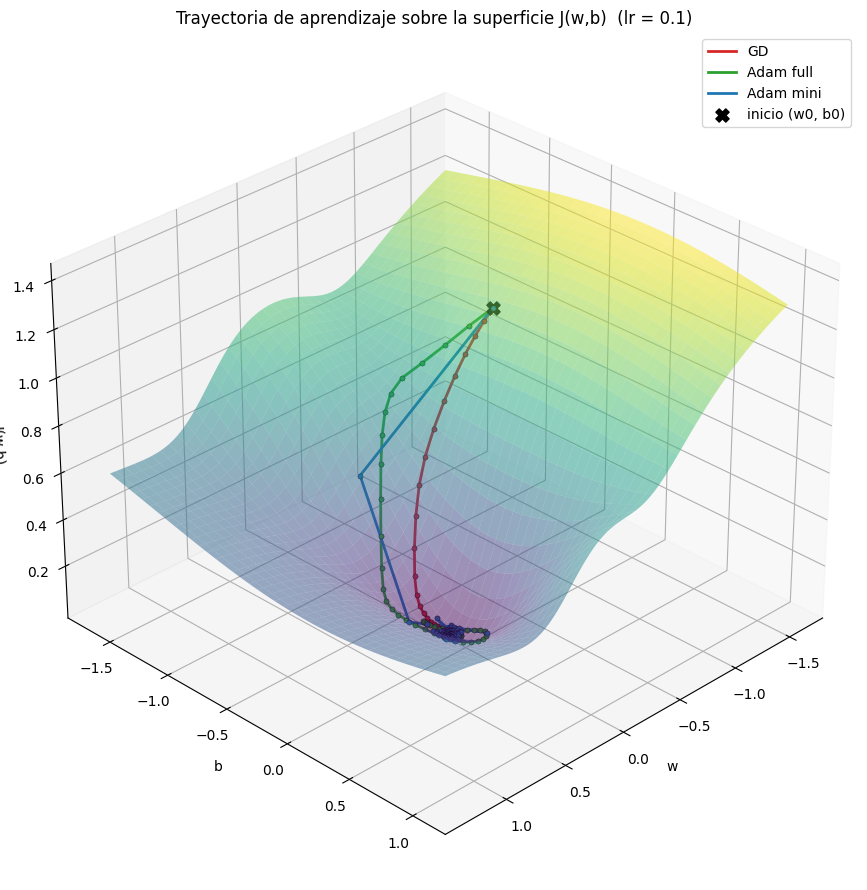

In [207]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Uso lr=0.1 porque los 3 convergen y se ve bien la trayectoria de cada optimizador
lr_3d = 0.1 

# Centro la grilla de modo que contenga tanto el punto inicial como los finales.
w_todos = np.concatenate([res[lr_3d]["path_w"] for res, _ in optimizadores.values()] + [[w0]])
b_todos = np.concatenate([res[lr_3d]["path_b"] for res, _ in optimizadores.values()] + [[b0]])
margen_w = 0.5 + 0.2 * (w_todos.max() - w_todos.min())
margen_b = 0.5 + 0.2 * (b_todos.max() - b_todos.min())

W = np.linspace(w_todos.min() - margen_w, w_todos.max() + margen_w, 120)
B = np.linspace(b_todos.min() - margen_b, b_todos.max() + margen_b, 120)
WW, BB = np.meshgrid(W, B)
JJ = np.zeros_like(WW)
for i in range(WW.shape[0]):
    for j in range(WW.shape[1]):
        JJ[i, j] = J_mse(WW[i, j], BB[i, j], x, y)

# Gráfico 3D: superficie + las 3 trayectorias, todas arrancando en (w0, b0)
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(WW, BB, JJ, alpha=0.5, cmap="viridis", linewidth=0, antialiased=True)

for nombre, (res, color) in optimizadores.items():
    pw, pb, pJ = res[lr_3d]["path_w"], res[lr_3d]["path_b"], res[lr_3d]["path_J"]
    ax.plot(pw, pb, pJ, color=color, lw=2.0, label=nombre)
    # un punto por época, del mismo color que la línea, para ver dónde va cayendo
    ax.scatter(pw, pb, pJ, color=color, s=14, edgecolors="black", linewidths=0.3, depthshade=False)

# marco el punto de partida común
ax.scatter([w0], [b0], [J_mse(w0, b0, x, y)], s=90, c="black", marker="X", label="inicio (w0, b0)")

ax.set_title(f"Trayectoria de aprendizaje sobre la superficie J(w,b)  (lr = {lr_3d})")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w,b)")
ax.view_init(elev=30, azim=45)
ax.legend()
plt.tight_layout()
plt.show()


**Conclusiones**

La superficie tiene una meseta alta arriba (lo amarillo) y un valle abajo (lo azul-violeta), que es donde está el mínimo. Los tres salen del mismo punto `(w0, b0)`, que es la X negra marcada en la gráfica, y los tres terminan en el fondo del valle, siguiendo una trayectoria distinta.

* GD: es el que baja más derecho. Va siguiendo la pendiente casi en línea recta con pasos de casi el mismo tamaño y sobre el final los pasos se hacen cortos, porque cerca del fondo el gradiente se hace chico. 
* Adam full-batch: en vez de bajar derecho se abre para la izquierda, hace una panza grande y recién ahí cae al valle. Esa panza es el momentum, que al principio lo empuja de más y después lo tiene que corregir. Al final los pasos se hacen más chicos y da "una vuelta" en el valle hasta que llega al óptimo. La vuelta que vemos se condice con el aumento de la función de costo con respecto a GD en la época 20 en la gráfica de época vs costo para lr 0.1.
* Adam mini-batch: hace el camino con un codo bien marcado, primero se corre para el costado y después baja casi de una al fondo en dos épocas. Como toca los parámetros una vez por cada lote de 32, mete un montón de pasos por época y por eso llega rapidísimo. En el fondo se ve la manchita azul amontonada, que es el modelo dando vueltas alrededor del mínimo en lugar de frenar justo ahí.


### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual. Y la idea sería que una vez que el modelo ya esté listo y entrenado, se use para estimar apartir de datos de clientes relativamente nuevos, que solo llevan entre 3 a 5 visitas y compras en la tienda.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage, ocurre mucho cuando se usan proporciones como nuevas columnas**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.